In [1]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('smartcart_customers.csv')

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.isnull().sum()
df.shape

(2240, 22)

In [5]:
df['Income'] = df['Income'].fillna(df['Income'].median())

In [6]:
df['Age'] = 2026 - df['Year_Birth']
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age'],
      dtype='str')

In [7]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst = True)

reference_date = df['Dt_Customer'].max()

df['customer_tenure_days'] = (reference_date - df['Dt_Customer']).dt.days

In [8]:
df['Total_Spending'] = df['MntWines'] + df['MntFruits'] + df['MntFruits'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']
df['Total_Children'] = df['Kidhome'] + df['Teenhome']
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,Total_Spending,Total_Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1159,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,22,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,698,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,37,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,347,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,9,3,4,5,0,0,59,381,1202,1
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,8,2,5,7,0,0,80,19,414,3
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,2,3,13,6,0,0,45,155,1072,0
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,6,5,10,3,0,0,70,156,659,1


In [9]:
df['Education'].value_counts()

df['Education'] = df['Education'].replace({
    'Basic' : 'undergraduate', '2n Cycle' : 'undergraduate',
    'Graduation' : 'Graduate',
    'PhD' : 'Postgraduate', 'Master' : 'Postgraduate'
})

In [10]:
df['Education'].value_counts()

Education
Graduate         1127
Postgraduate      856
undergraduate     257
Name: count, dtype: int64

In [11]:
df['Living_with'] = df['Marital_Status'].replace({
    'Married' : 'Partner', 'Together' : 'Partner',
    'Single' : 'Alone', 'Absurd' : 'Alone', 'YOLO' : 'Alone', 'Divorced' : 'Alone', 'Widow' : 'Alone'
})

In [12]:
df['Living_with'].value_counts()
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'customer_tenure_days', 'Total_Spending',
       'Total_Children', 'Living_with'],
      dtype='str')

In [13]:
cols = ['Year_Birth', 'ID', 'Marital_Status', 'Kidhome', 'Teenhome', 'Dt_Customer', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df = df.drop(columns = cols)

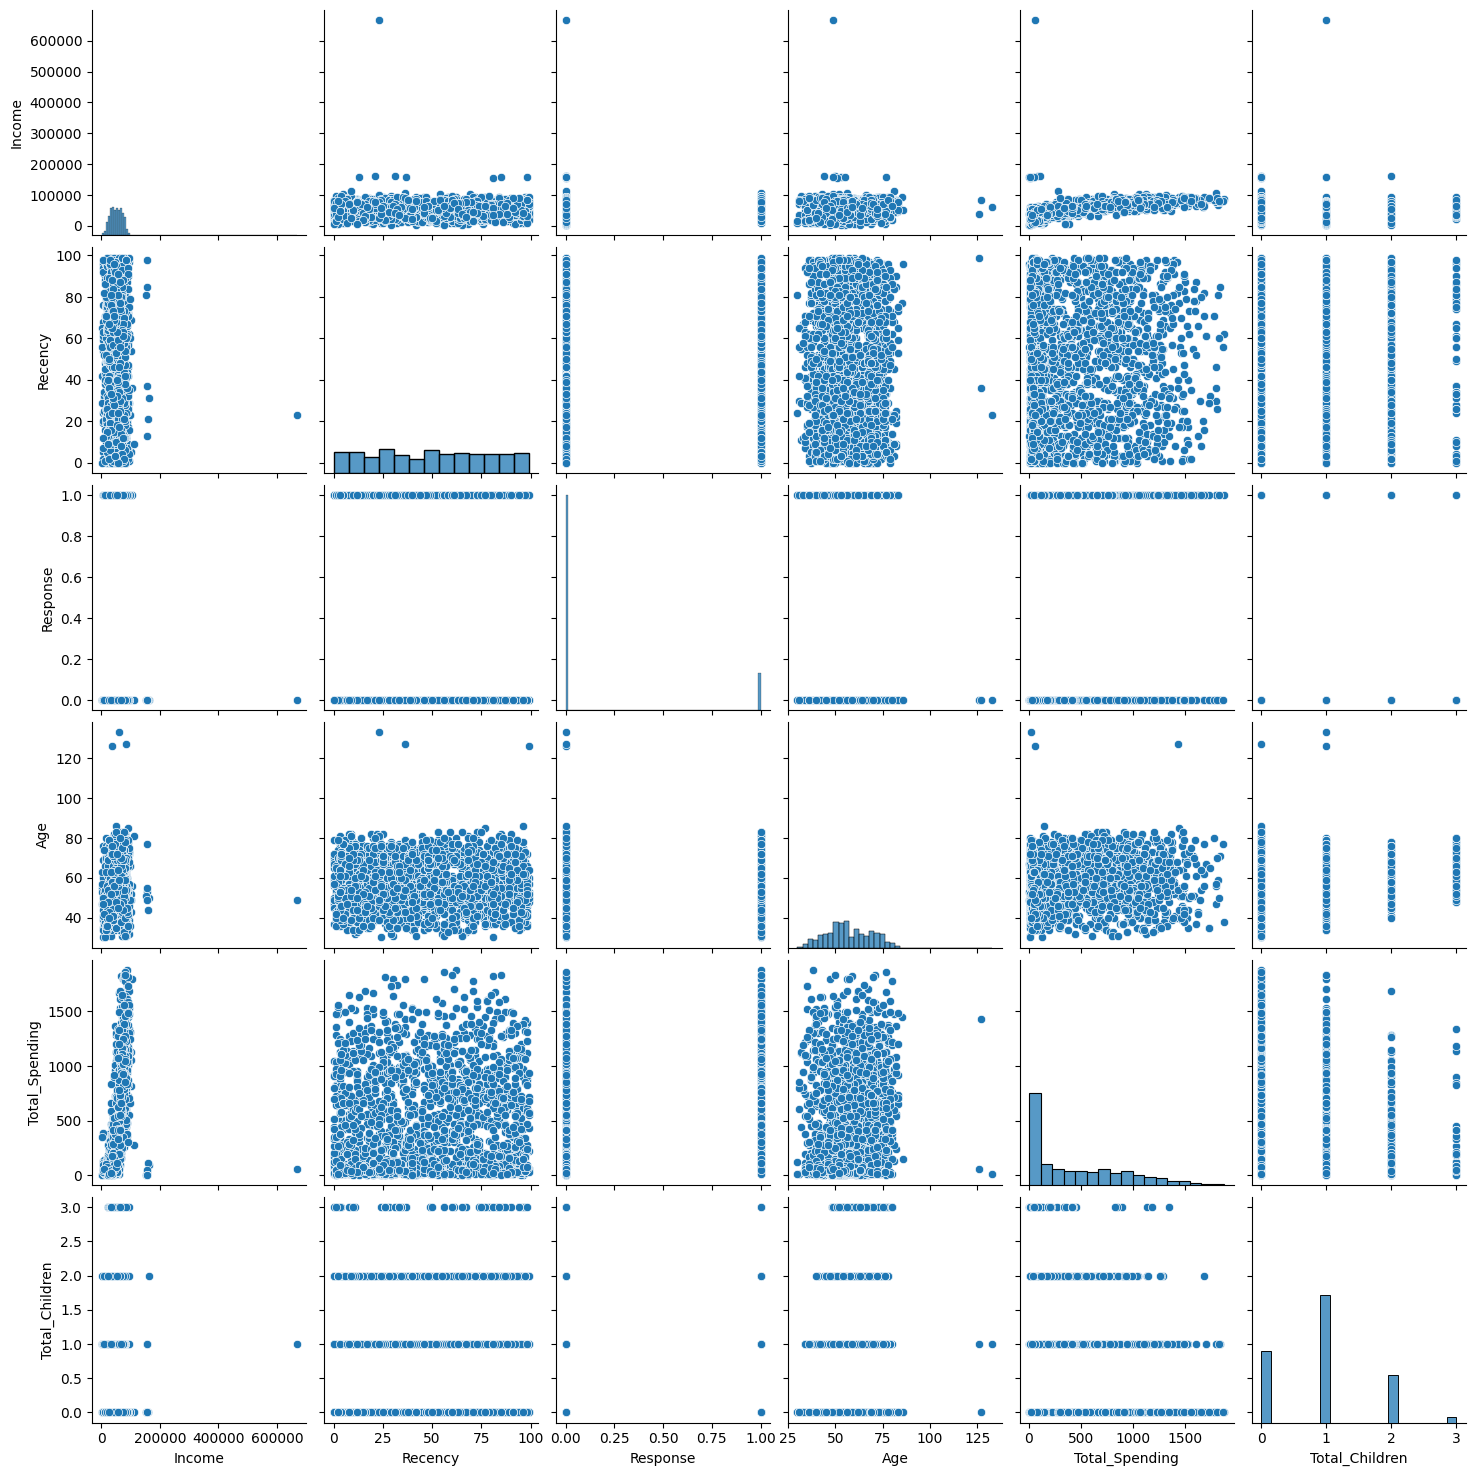

In [14]:
cols = ['Income', 'Recency', 'Response', 'Age', 'Total_Spending', 'Total_Children']
sb.pairplot(df[cols])

In [15]:
df = df[df['Age'] < 90]
df = df[df['Income'] < 600000]
print('Data size without outliers:', len(df))

Data size without outliers: 2236


<Axes: >

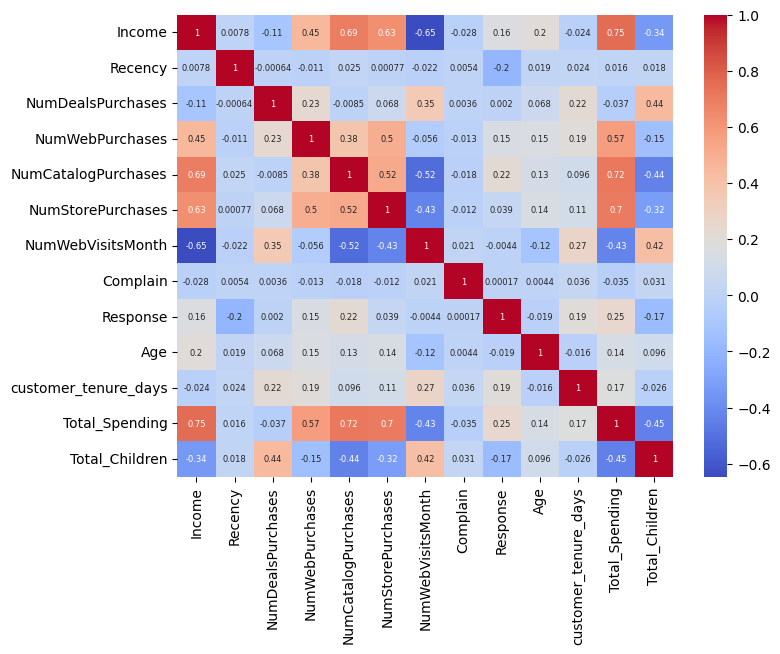

In [16]:
corr = df.corr(numeric_only = True)
plt.figure(figsize = (8, 6))
sb.heatmap(
    corr,
    annot = True,
    cmap = 'coolwarm',
    annot_kws = {'size' : 6}
)

In [17]:
df.info()

<class 'pandas.DataFrame'>
Index: 2236 entries, 0 to 2239
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Education             2236 non-null   str    
 1   Income                2236 non-null   float64
 2   Recency               2236 non-null   int64  
 3   NumDealsPurchases     2236 non-null   int64  
 4   NumWebPurchases       2236 non-null   int64  
 5   NumCatalogPurchases   2236 non-null   int64  
 6   NumStorePurchases     2236 non-null   int64  
 7   NumWebVisitsMonth     2236 non-null   int64  
 8   Complain              2236 non-null   int64  
 9   Response              2236 non-null   int64  
 10  Age                   2236 non-null   int64  
 11  customer_tenure_days  2236 non-null   int64  
 12  Total_Spending        2236 non-null   int64  
 13  Total_Children        2236 non-null   int64  
 14  Living_with           2236 non-null   str    
dtypes: float64(1), int64(12), str(2)
memo

In [18]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ohe = OneHotEncoder()

cat_cols = ['Education', 'Living_with']

enc_cols = ohe.fit_transform(df[cat_cols])

enc_df = pd.DataFrame(enc_cols.toarray(), columns = ohe.get_feature_names_out(cat_cols), index = df.index)

df_encoded = pd.concat([df.drop(columns = cat_cols), enc_df], axis = 1)

In [19]:
df_encoded.head()
df_encoded.shape

(2236, 18)

In [20]:
x = df_encoded
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [21]:
x_scaled

array([[ 0.28894655,  0.30685572,  0.34873831, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.262003  , -0.38397129, -0.16869955, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.91842301, -0.7984675 , -0.68613742, ..., -0.35877969,
        -0.74204052,  0.74204052],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -0.35877969,
        -0.74204052,  0.74204052]], shape=(2236, 18))

In [22]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 3)
x_pca = pca.fit_transform(x_scaled)
pca.explained_variance_ratio_

array([0.22880765, 0.11386642, 0.10429182])

Text(0.5, 0.92, '3D Projection')

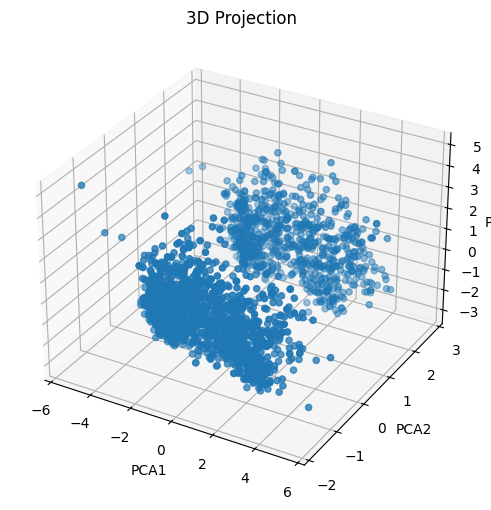

In [23]:
fig = plt.figure(figsize = (8,6))
ax = fig.add_subplot(111, projection = '3d')
ax.scatter(x_pca[:, 0], x_pca[:, 1], x_pca[:, 2])
ax.set_xlabel('PCA1')
ax.set_ylabel('PCA2')
ax.set_zlabel('PCA3')
ax.set_title('3D Projection')

In [27]:
!pip install kneed
from sklearn.cluster import KMeans, AgglomerativeClustering
from kneed import KneeLocator

wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    kmeans.fit_predict(x_pca)
    wcss.append(kmeans.inertia_)

In [28]:
knee = KneeLocator(range(1,11), wcss, curve = 'convex', direction = 'decreasing')
print('Best k = ', knee.elbow)

Best k =  3


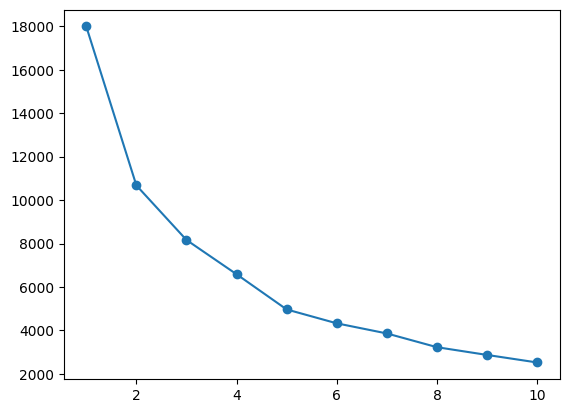

In [29]:
plt.plot(range(1,11), wcss, marker = 'o')

In [30]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    labels = kmeans.fit_predict(x_pca)
    score = silhouette_score(x_pca, labels)
    scores.append(score)

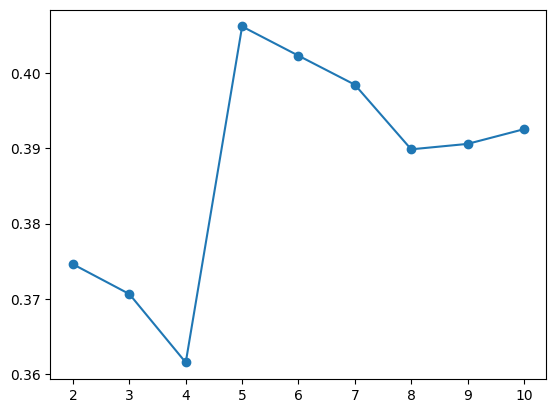

In [31]:
plt.plot(range(2,11), scores, marker = 'o')

Text(0.5, 0.92, '3D Projection')

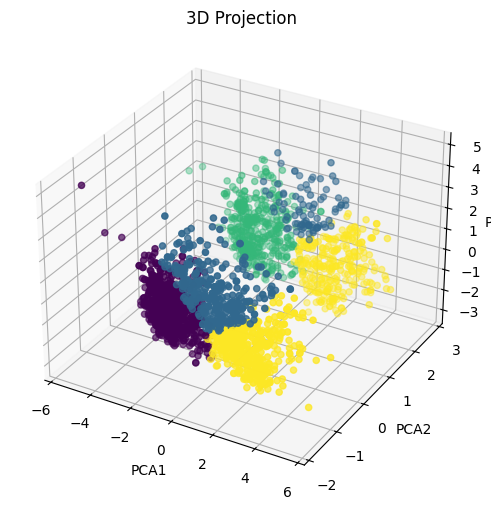

In [32]:
kmeans = KMeans(n_clusters = 4, random_state = 42)
labels_kmeans = kmeans.fit_predict(x_pca)

fig = plt.figure(figsize = (8,6))
ax = fig.add_subplot(111, projection = '3d')
ax.scatter(x_pca[:, 0], x_pca[:, 1], x_pca[:, 2], c = labels_kmeans )
ax.set_xlabel('PCA1')
ax.set_ylabel('PCA2')
ax.set_zlabel('PCA3')
ax.set_title('3D Projection')

Text(0.5, 0.92, '3D Projection')

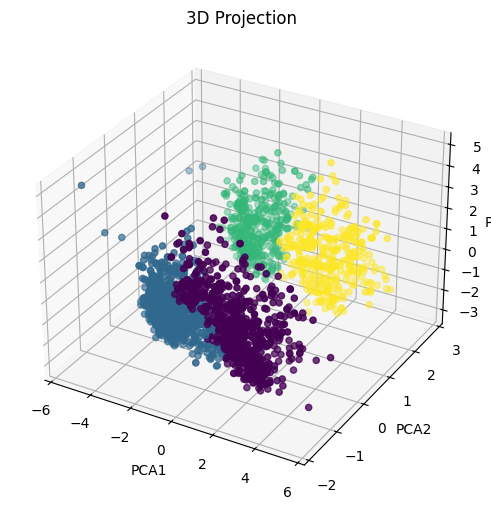

In [ ]:
agglo = AgglomerativeClustering(n_clusters = 4, linkage = 'ward')
labels_agg = kmeans.fit_predict(x_pca)

fig = plt.figure(figsize = (8,6))
ax = fig.add_subplot(111, projection = '3d')
ax.scatter(x_pca[:, 0], x_pca[:, 1], x_pca[:, 2], c = labels_agg )
ax.set_xlabel('PCA1')
ax.set_ylabel('PCA2')
ax.set_zlabel('PCA3')
ax.set_title('3D Projection')

In [34]:
x['clusters'] = labels_agg
x.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_undergraduate,Living_with_Alone,Living_with_Partner,clusters
0,58138.0,58,3,8,10,4,7,0,1,69,663,1159,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,22,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,698,0,1.0,0.0,0.0,0.0,1.0,0
3,26646.0,26,2,2,0,4,6,0,0,42,139,37,1,1.0,0.0,0.0,0.0,1.0,1
4,58293.0,94,5,5,3,6,5,0,0,45,161,347,1,0.0,1.0,0.0,0.0,1.0,0


In [35]:
x['clusters'].value_counts()

clusters
1    777
0    667
2    439
3    353
Name: count, dtype: int64

<Axes: xlabel='Total_Spending', ylabel='Income'>

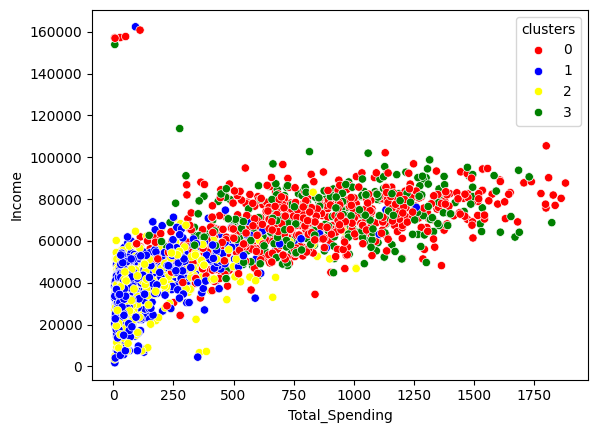

In [36]:
sb.scatterplot(x = x['Total_Spending'], y = x['Income'], palette = ['red', 'blue', 'yellow', 'green'], hue = x['clusters'])

In [37]:
cluster_summary = x.groupby('clusters').mean()
print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         68916.426537  48.481259           2.455772         5.808096   
1         37129.527027  49.555985           2.319176         2.597169   
2         37116.903189  48.243736           2.555809         2.797267   
3         70976.842776  50.433428           1.810198         5.722380   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    4.820090           8.253373           4.125937  0.004498   
1                    0.770914           3.693694           6.391248  0.012870   
2                    0.876993           3.665148           6.537585  0.011390   
3                    4.974504           8.427762           3.696884  0.005666   

          Response        Age  customer_tenure_days  Total_Spending  \
clu

In [38]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(pca, "pca.pkl")
joblib.dump(ohe, "encoder.pkl")

['encoder.pkl']

In [41]:
x.groupby("clusters").mean(numeric_only=True)

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_undergraduate,Living_with_Alone,Living_with_Partner
clusters,,,,,,,,,,,,,,,,,,
0,68916.426537,48.481259,2.455772,5.808096,4.820090,8.253373,4.125937,0.004498,0.160420,59.664168,373.076462,838.827586,0.655172,0.439280,0.487256,0.073463,0.000000,1.000000
1,37129.527027,49.555985,2.319176,2.597169,0.770914,3.693694,6.391248,0.012870,0.065637,54.893179,335.034749,132.653797,1.243243,0.549550,0.292149,0.158301,0.002574,0.997426
2,37116.903189,48.243736,2.555809,2.797267,0.876993,3.665148,6.537585,0.011390,0.152620,55.635535,344.148064,142.391800,1.282460,0.485194,0.382688,0.132118,1.000000,0.000000
3,70976.842776,50.433428,1.810198,5.722380,4.974504,8.427762,3.696884,0.005666,0.308782,58.946176,370.515581,893.155807,0.453258,0.546742,0.382436,0.070822,1.000000,0.000000
